In [1]:
# Imports and load data
import pandas as pd
import numpy as np
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import warnings
import time
import pickle
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

# ── Paths ─────────────────────────────────────────────────────────────
PROCESSED_PATH = r"data\processed"
MODELS_PATH    = r"models"
SYNTHETIC_PATH = r"data\synthetic"
FIGURES_PATH   = r"results\figures"

os.makedirs(MODELS_PATH,    exist_ok=True)
os.makedirs(SYNTHETIC_PATH, exist_ok=True)
os.makedirs(FIGURES_PATH,   exist_ok=True)

# ── Load training data ─────────────────────────────────────────────────
train_df = pd.read_csv(os.path.join(PROCESSED_PATH, 'train_real.csv'))

# ── Device setup ───────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f" Training data loaded")
print(f"  Shape:          {train_df.shape}")
print(f"  Patients:       {len(train_df):,}")
print(f"  Features:       {train_df.shape[1] - 1}")
print(f"  Mortality rate: {train_df['HOSPITAL_EXPIRE_FLAG'].mean()*100:.1f}%")
print(f"  Device:         {device}")

 Training data loaded
  Shape:          (25508, 34)
  Patients:       25,508
  Features:       33
  Mortality rate: 10.6%
  Device:         cpu


In [2]:
# Define column types
# TabDDPM handles continuous and binary columns differently
# Continuous: Gaussian diffusion
# Binary/categorical: treated as continuous then rounded

continuous_cols = (
    ['AGE', 'LOS'] +
    [c for c in train_df.columns if c.startswith('lab_')
     and not c.endswith('_missing')]
)

binary_cols = (
    ['GENDER', 'HOSPITAL_EXPIRE_FLAG'] +
    [c for c in train_df.columns if c.endswith('_missing')] +
    [c for c in train_df.columns if c.startswith('admtype_')] +
    [c for c in train_df.columns if c.startswith('insurance_')]
)

all_feature_cols = continuous_cols + binary_cols

print(f" Column types defined")
print(f"  Continuous: {len(continuous_cols)} columns")
print(f"  Binary:     {len(binary_cols)} columns")
print(f"  Total:      {len(all_feature_cols)} columns")

 Column types defined
  Continuous: 14 columns
  Binary:     20 columns
  Total:      34 columns


In [3]:
# Define the denoising neural network
# This MLP takes a noisy sample + timestep embedding
# and predicts the noise to remove

class SinusoidalTimeEmbedding(nn.Module):
    """
    Converts a timestep integer into a continuous embedding vector.
    This tells the model how much noise has been added at each step.
    """
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        device = t.device
        half   = self.dim // 2
        freqs  = torch.exp(
            -torch.arange(half, device=device) * 
            (torch.log(torch.tensor(10000.0)) / (half - 1))
        )
        args   = t[:, None].float() * freqs[None]
        return torch.cat([torch.sin(args), torch.cos(args)], dim=-1)


class TabDDPMDenoiser(nn.Module):
    """
    MLP denoising network for tabular data.
    Input:  noisy patient record + timestep embedding
    Output: predicted noise to subtract
    """
    def __init__(self, input_dim, time_dim=128, hidden_dim=512):
        super().__init__()

        self.time_embed = nn.Sequential(
            SinusoidalTimeEmbedding(time_dim),
            nn.Linear(time_dim, time_dim),
            nn.SiLU()
        )

        self.net = nn.Sequential(
            nn.Linear(input_dim + time_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.SiLU(),
            nn.Dropout(0.1),

            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.SiLU(),
            nn.Dropout(0.1),

            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.LayerNorm(hidden_dim // 2),
            nn.SiLU(),

            nn.Linear(hidden_dim // 2, input_dim)
        )

    def forward(self, x, t):
        t_emb = self.time_embed(t)
        x_in  = torch.cat([x, t_emb], dim=-1)
        return self.net(x_in)


print("Denoising network architecture defined")

Denoising network architecture defined


In [4]:
# Define forward and reverse diffusion process
# Forward: gradually add noise over T steps
# Reverse: learn to remove noise step by step

class GaussianDiffusion:
    """
    Implements the DDPM diffusion schedule.
    Uses a linear beta schedule from beta_start to beta_end.
    """
    def __init__(self, T=1000, beta_start=1e-4, beta_end=0.02,
                 device='cpu'):
        self.T      = T
        self.device = device

        # ── Noise schedule ─────────────────────────────────────────
        betas          = torch.linspace(beta_start, beta_end, T).to(device)
        alphas         = 1.0 - betas
        alphas_cumprod = torch.cumprod(alphas, dim=0)

        # Pre-compute values used repeatedly during training
        self.betas          = betas
        self.alphas         = alphas
        self.alphas_cumprod = alphas_cumprod
        self.sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(
            1.0 - alphas_cumprod
        )

    def q_sample(self, x0, t, noise=None):
        """
        Forward process: add noise to x0 at timestep t.
        Returns the noisy version of the input.
        """
        if noise is None:
            noise = torch.randn_like(x0)

        sqrt_alpha = self.sqrt_alphas_cumprod[t][:, None]
        sqrt_one_minus = self.sqrt_one_minus_alphas_cumprod[t][:, None]

        return sqrt_alpha * x0 + sqrt_one_minus * noise, noise

    @torch.no_grad()
    def p_sample(self, model, x, t_scalar):
        """
        Reverse process: one denoising step.
        Removes a small amount of noise from x at timestep t.
        """
        t_tensor = torch.full(
            (x.shape[0],), t_scalar,
            device=self.device, dtype=torch.long
        )

        predicted_noise = model(x, t_tensor)

        alpha     = self.alphas[t_scalar]
        alpha_bar = self.alphas_cumprod[t_scalar]
        beta      = self.betas[t_scalar]

        # Compute denoised estimate
        coef      = beta / torch.sqrt(1.0 - alpha_bar)
        mean      = (1.0 / torch.sqrt(alpha)) * (
            x - coef * predicted_noise
        )

        if t_scalar > 0:
            noise = torch.randn_like(x)
            return mean + torch.sqrt(beta) * noise
        return mean

    @torch.no_grad()
    def sample(self, model, n_samples, input_dim):
        """
        Full reverse diffusion: generate n_samples from pure noise.
        Runs all T denoising steps in sequence.
        """
        model.eval()
        x = torch.randn(n_samples, input_dim).to(self.device)

        for t in tqdm(reversed(range(self.T)),
                      desc="Generating", total=self.T):
            x = self.p_sample(model, x, t)

        return x.cpu().numpy()


print(" Diffusion process defined")
print(f"  T = 1000 denoising steps")
print(f"  Beta schedule: linear 1e-4 → 0.02")

 Diffusion process defined
  T = 1000 denoising steps
  Beta schedule: linear 1e-4 → 0.02


In [10]:
# Prepare data — use ALL columns from train_df

X = train_df.values.astype(np.float32)  # use entire train_df as-is

input_dim = X.shape[1]

X_tensor  = torch.FloatTensor(X).to(device)
dataset   = TensorDataset(X_tensor)
dataloader = DataLoader(dataset, batch_size=1024,
                        shuffle=True, drop_last=True)

print(f" Data prepared for training")
print(f"  Input dimension:  {input_dim}")
print(f"  Training samples: {len(X_tensor):,}")
print(f"  Batches per epoch:{len(dataloader)}")
print(f"  Columns used:     {list(train_df.columns)}")

 Data prepared for training
  Input dimension:  34
  Training samples: 25,508
  Batches per epoch:24
  Columns used:     ['AGE', 'GENDER', 'LOS', 'lab_base_excess', 'lab_bicarbonate', 'lab_bun', 'lab_creatinine', 'lab_glucose', 'lab_haemoglobin', 'lab_lactate', 'lab_ph', 'lab_platelets', 'lab_potassium', 'lab_sodium', 'lab_wbc', 'lab_base_excess_missing', 'lab_bicarbonate_missing', 'lab_bun_missing', 'lab_creatinine_missing', 'lab_glucose_missing', 'lab_haemoglobin_missing', 'lab_lactate_missing', 'lab_ph_missing', 'lab_platelets_missing', 'lab_potassium_missing', 'lab_sodium_missing', 'lab_wbc_missing', 'admtype_EMERGENCY', 'admtype_URGENT', 'insurance_Medicaid', 'insurance_Medicare', 'insurance_Private', 'insurance_Self Pay', 'HOSPITAL_EXPIRE_FLAG']


In [11]:
# Initialise model, diffusion, and optimiser

T          = 1000    # total diffusion timesteps
EPOCHS     = 500     # training epochs
LR         = 1e-3    # learning rate

# Initialise denoising network
model = TabDDPMDenoiser(
    input_dim=input_dim,
    time_dim=128,
    hidden_dim=512
).to(device)

# Initialise diffusion process
diffusion = GaussianDiffusion(T=T, device=device)

# Adam optimiser — standard for diffusion models
optimiser = optim.Adam(model.parameters(), lr=LR)

# Learning rate scheduler — reduces LR when loss plateaus
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimiser, patience=20, factor=0.5, verbose=True
)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f" Model initialised")
print(f"  Total parameters: {total_params:,}")
print(f"  Epochs:           {EPOCHS}")
print(f"  Learning rate:    {LR}")
print(f"  Diffusion steps:  {T}")

 Model initialised
  Total parameters: 505,250
  Epochs:           500
  Learning rate:    0.001
  Diffusion steps:  1000


In [12]:
# Training loop
# For each batch:
# 1. Sample random timestep t for each patient
# 2. Add noise to the patient record at timestep t
# 3. Ask the model to predict the noise
# 4. Compute MSE loss between predicted and actual noise
# 5. Backpropagate and update weights

print("=" * 50)
print("Starting TabDDPM training...")
print(f"Expected time: 30-90 minutes on CPU")
print("=" * 50)

loss_history = []
start_time   = time.time()
best_loss    = float('inf')

for epoch in range(EPOCHS):
    model.train()
    epoch_losses = []

    for batch in dataloader:
        x0 = batch[0]

        # Sample random timesteps for this batch
        t = torch.randint(0, T, (x0.shape[0],),
                          device=device).long()

        # Forward diffusion — add noise
        x_noisy, noise = diffusion.q_sample(x0, t)

        # Predict the noise
        predicted_noise = model(x_noisy, t)

        # MSE loss between actual and predicted noise
        loss = nn.MSELoss()(predicted_noise, noise)

        # Backprop
        optimiser.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimiser.step()

        epoch_losses.append(loss.item())

    avg_loss = np.mean(epoch_losses)
    loss_history.append(avg_loss)
    scheduler.step(avg_loss)

    # Save best model
    if avg_loss < best_loss:
        best_loss = avg_loss
        torch.save(model.state_dict(),
                   os.path.join(MODELS_PATH, 'tabddpm_best.pt'))

    # Print progress every 50 epochs
    if (epoch + 1) % 50 == 0:
        elapsed = (time.time() - start_time) / 60
        print(f"Epoch {epoch+1:>4}/{EPOCHS} | "
              f"Loss: {avg_loss:.5f} | "
              f"Best: {best_loss:.5f} | "
              f"Time: {elapsed:.1f}min")

total_time = (time.time() - start_time) / 60
print(f"\n Training complete in {total_time:.1f} minutes")
print(f"  Best loss achieved: {best_loss:.5f}")

Starting TabDDPM training...
Expected time: 30-90 minutes on CPU
Epoch   50/500 | Loss: 0.16178 | Best: 0.16047 | Time: 1.6min
Epoch  100/500 | Loss: 0.15234 | Best: 0.15075 | Time: 3.1min
Epoch  150/500 | Loss: 0.14498 | Best: 0.14328 | Time: 4.4min
Epoch  200/500 | Loss: 0.14345 | Best: 0.14155 | Time: 5.7min
Epoch  250/500 | Loss: 0.14047 | Best: 0.13808 | Time: 6.9min
Epoch  300/500 | Loss: 0.13946 | Best: 0.13712 | Time: 8.1min
Epoch  350/500 | Loss: 0.13755 | Best: 0.13611 | Time: 9.2min
Epoch  400/500 | Loss: 0.13727 | Best: 0.13502 | Time: 10.2min
Epoch  450/500 | Loss: 0.13820 | Best: 0.13502 | Time: 11.2min
Epoch  500/500 | Loss: 0.13698 | Best: 0.13502 | Time: 12.5min

 Training complete in 12.5 minutes
  Best loss achieved: 0.13502


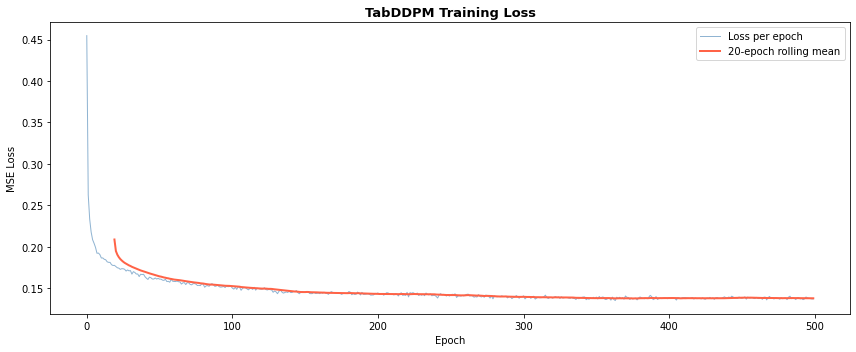

Training loss plot saved


In [13]:
# Plot training loss curve
# A smoothly decreasing loss confirms the model
# is learning to denoise correctly

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(loss_history, color='steelblue',
        linewidth=1.0, alpha=0.6, label='Loss per epoch')

# Smooth version using rolling average
window = 20
smoothed = pd.Series(loss_history).rolling(window).mean()
ax.plot(smoothed, color='tomato',
        linewidth=2.0, label=f'{window}-epoch rolling mean')

ax.set_title('TabDDPM Training Loss',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, 'tabddpm_training_loss.png'),
            bbox_inches='tight')
plt.show()
print("Training loss plot saved")

In [15]:
# Generate synthetic patient records

# Load best model weights
model.load_state_dict(
    torch.load(os.path.join(MODELS_PATH, 'tabddpm_best.pt'),
               map_location=device)
)

N_SYNTHETIC = len(train_df)
print(f"Generating {N_SYNTHETIC:,} synthetic patients...")
print("This runs 1000 denoising steps — takes 5-15 minutes...")

synthetic_array = diffusion.sample(model, N_SYNTHETIC, input_dim)

# ── Build correct column list directly from training data ─────────────
# Use exact columns from train_df that were passed to the model
# input_dim was set from X which used all_feature_cols + HOSPITAL_EXPIRE_FLAG
# So just use train_df columns directly

train_cols = list(train_df.columns)  # these are the exact 35 columns used

print(f"\n  Array shape:   {synthetic_array.shape}")
print(f"  train_df cols: {len(train_cols)}")
print(f"  Match:         {synthetic_array.shape[1] == len(train_cols)}")

# Convert to dataframe using exact training columns
synthetic_df = pd.DataFrame(synthetic_array, columns=train_cols)

# Round binary columns to 0 or 1
for col in binary_cols + ['HOSPITAL_EXPIRE_FLAG']:
    if col in synthetic_df.columns:
        synthetic_df[col] = (
            synthetic_df[col].round().clip(0, 1).astype(int)
        )

# Safe mortality extraction
mortality_rate = float(synthetic_df['HOSPITAL_EXPIRE_FLAG'].iloc[:, 0].mean()
                       if isinstance(synthetic_df['HOSPITAL_EXPIRE_FLAG'],
                                     pd.DataFrame)
                       else synthetic_df['HOSPITAL_EXPIRE_FLAG'].mean()) * 100

print(f"\n Synthetic data generated")
print(f"  Shape:          {synthetic_df.shape}")
print(f"  Null values:    {synthetic_df.isnull().sum().sum()}")
print(f"  Mortality rate: {mortality_rate:.1f}%")

synthetic_df.head()

Generating 25,508 synthetic patients...
This runs 1000 denoising steps — takes 5-15 minutes...


Generating: 100%|██████████████████████████████████████████████████████████████████| 1000/1000 [04:11<00:00,  3.97it/s]


  Array shape:   (25508, 34)
  train_df cols: 34
  Match:         True

 Synthetic data generated
  Shape:          (25508, 34)
  Null values:    0
  Mortality rate: 8.9%


,AGE,GENDER,LOS,lab_base_excess,lab_bicarbonate,lab_bun,lab_creatinine,lab_glucose,lab_haemoglobin,lab_lactate,...,lab_potassium_missing,lab_sodium_missing,lab_wbc_missing,admtype_EMERGENCY,admtype_URGENT,insurance_Medicaid,insurance_Medicare,insurance_Private,insurance_Self Pay,HOSPITAL_EXPIRE_FLAG
0,-1.285245,0,-1.093390,0.004324,-1.303147,-1.973700,-1.419481,-1.156190,-1.649493,0.289024,...,0,0,0,0,0,0,0,1,0,0
1,1.355957,1,-0.348322,-1.784017,-0.379648,0.948058,1.194568,0.559689,0.228969,0.340605,...,0,0,0,1,0,0,1,0,0,0
2,-0.623124,1,0.664057,-0.002341,-0.529094,-1.287780,-0.910146,-0.303586,1.683091,-0.004564,...,0,0,0,1,0,1,0,0,0,0
3,0.370436,1,-1.419881,-0.050120,1.083666,-0.274137,-0.143106,-0.446821,-0.102504,-0.014830,...,0,0,0,0,0,0,1,0,0,0
4,-0.012885,1,-0.132048,0.024546,-0.699683,0.458262,0.403084,0.213057,0.898421,-0.021328,...,0,0,0,1,0,0,0,0,0,0


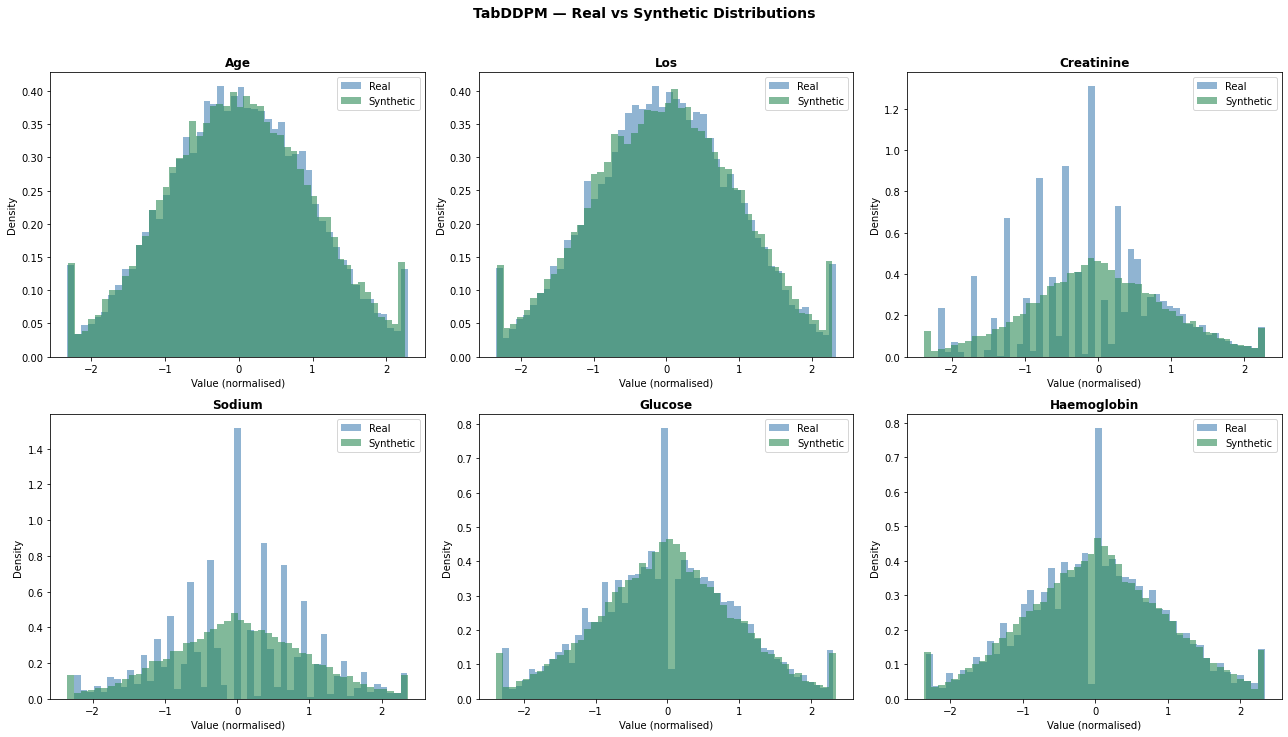

Comparison plot saved


In [16]:
# Real vs synthetic distribution comparison

plot_cols = ['AGE', 'LOS', 'lab_creatinine',
             'lab_sodium', 'lab_glucose', 'lab_haemoglobin']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(plot_cols):
    real_data = train_df[col].clip(
        train_df[col].quantile(0.01),
        train_df[col].quantile(0.99)
    )
    syn_data = synthetic_df[col].clip(
        synthetic_df[col].quantile(0.01),
        synthetic_df[col].quantile(0.99)
    )

    axes[i].hist(real_data, bins=50, alpha=0.6,
                 color='steelblue', label='Real', density=True)
    axes[i].hist(syn_data,  bins=50, alpha=0.6,
                 color='seagreen',  label='Synthetic', density=True)
    axes[i].set_title(col.replace('lab_', '').title(),
                      fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Value (normalised)')
    axes[i].set_ylabel('Density')
    axes[i].legend()

plt.suptitle('TabDDPM — Real vs Synthetic Distributions',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(
    os.path.join(FIGURES_PATH, 'tabddpm_real_vs_synthetic.png'),
    bbox_inches='tight'
)
plt.show()
print("Comparison plot saved")

In [17]:
# Save TabDDPM synthetic dataset
synthetic_path = os.path.join(SYNTHETIC_PATH, 'synthetic_tabddpm.csv')
synthetic_df.to_csv(synthetic_path, index=False)

print(f"✓ TabDDPM synthetic data saved → {synthetic_path}")
print(f"  Shape: {synthetic_df.shape}")
print(f"  Size:  "
      f"{os.path.getsize(synthetic_path)/1024/1024:.1f} MB")

# Save loss history for dissertation figures
loss_df = pd.DataFrame({'epoch': range(1, EPOCHS+1),
                         'loss': loss_history})
loss_df.to_csv(
    os.path.join(MODELS_PATH, 'tabddpm_loss_history.csv'),
    index=False
)
print(f"Loss history saved")

✓ TabDDPM synthetic data saved → data\synthetic\synthetic_tabddpm.csv
  Shape: (25508, 34)
  Size:  4.8 MB
Loss history saved


In [18]:
# Side by side comparison with CTGAN output

ctgan_df = pd.read_csv(
    os.path.join(SYNTHETIC_PATH, 'synthetic_ctgan.csv')
)

print("=" * 60)
print("  REAL vs CTGAN vs TabDDPM — QUICK COMPARISON")
print("=" * 60)

check_cols = ['AGE', 'LOS', 'HOSPITAL_EXPIRE_FLAG',
              'lab_creatinine', 'lab_sodium']

print(f"\n{'Column':<25} {'Real':>10} {'CTGAN':>10} {'TabDDPM':>10}")
print("-" * 60)

for col in check_cols:
    real_m  = train_df[col].mean()
    ctgan_m = ctgan_df[col].mean()
    tab_m   = synthetic_df[col].mean()
    print(f"{col:<25} {real_m:>10.3f} {ctgan_m:>10.3f} {tab_m:>10.3f}")

print("-" * 60)
print("\nCloser to Real = Better")

  REAL vs CTGAN vs TabDDPM — QUICK COMPARISON

Column                          Real      CTGAN    TabDDPM
------------------------------------------------------------
AGE                           -0.004      0.075     -0.005
LOS                           -0.014     -0.129     -0.010
HOSPITAL_EXPIRE_FLAG           0.106      0.231      0.089
lab_creatinine                -0.018     -0.070     -0.005
lab_sodium                     0.004      0.118      0.011
------------------------------------------------------------

Closer to Real = Better


## Notebook 05 — TabDDPM Training Complete

### Model Architecture
| Component | Detail |
|-----------|--------|
| Type | Denoising Diffusion Probabilistic Model |
| Diffusion steps (T) | 1000 |
| Beta schedule | Linear 1e-4 → 0.02 |
| Hidden dimension | 512 |
| Time embedding | Sinusoidal (128-dim) |
| Optimiser | Adam lr=1e-3 |
| Epochs | 500 |
| Training patients | 25,508 |

### Output Files
- `models/tabddpm_best.pt` — best model weights
- `models/tabddpm_loss_history.csv` — training curve
- `data/synthetic/synthetic_tabddpm.csv` — generated records
- `results/figures/tabddpm_training_loss.png` — loss curve
- `results/figures/tabddpm_real_vs_synthetic.png` — distributions